In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from Hawkes_functions import (
    DHP,
    CHP, CHP_plot, CHP_IC, CHP_IC_plot,
    neg_log_likelihood, hawkes_residuals,
    neg_log_likelihood_bivariate, hawkes_residuals_bivariate,
    spectral_det, trace_1, trace_2,
    engle_russell_ed_test, _default_bivariate_bounds,
    fit_univariate, univariate_goodness_of_fit, pass_rate_univariate,
    simulate_bivariate, fit_bivariate, bivariate_goodness_of_fit,
    pass_rate_bivariate_sim,pass_rate_windows,fit_bivariate_sum_exp,neg_log_likelihood_bivariate_sum_exp,
    hawkes_residuals_bivariate_sum_exp,bivariate_goodness_of_fit_sum_exp,pass_rate_by_window_size,_eval_window_sum_exp
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.optimize import minimize, NonlinearConstraint,LinearConstraint
from scipy.stats import norm
from scipy import stats


from scipy.stats import kstest, expon
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from tick.hawkes import SimuHawkesExpKernels

In [ ]:
import nest_asyncio
from tardis_dev import download_datasets_async
import glob, pandas as pd

nest_asyncio.apply()

await download_datasets_async(
    exchange="binance",
    data_types=["trades"],
    from_date="2026-09-01",
    to_date="2026-09-02",
    symbols=["BTCUSDT"],
    download_dir="./tardis_data",
)


files = glob.glob("./tardis_data/*.csv.gz")
print("Fichiers téléchargés :", files)

df = pd.read_csv(files[0])

In [ ]:
# Make the DataFrame workable for Hawkes processes

df_total_hawkes = build_hawkes_dataframe(df: pd.DataFrame) 

# Extract a window of 5 mins at 1:00pm

df_hawkes = extract_time_window(df_total_hawkes['time_stamp'], df_total_hawkes['side'], start=13*3600, duration=5*60)

# Initialization of Hawkes Parameters : empirical way using the window

theta_init, bounds, constraints = initialize_hawkes_params(t_win: np.ndarray, side_win: np.ndarray)

Δt =0  : 0


In [ ]:
# Fit of a bivariate Hawkes on the BTC/USDT using exp kernel

resultat = fit_bivariate(df_hawkes,
                  theta_init=theta_init,
                  method='trust-constr',
                  bounds=bounds,
                  constraints=None,
                  verbose=False)

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)


The maximum number of function evaluations is exceeded.
Number of iterations: 2000, function evaluations: 18000, CG iterations: 6290, optimality: 1.33e-01, constraint violation: 0.00e+00, execution time: 1.4e+02 s.

--- Bivariate : Estimated results ---
Succès de l'optimisation : False
Statut                   : The maximum number of function evaluations is exceeded.

[Baseline intensity - mu]
mu1 (Dimension 1) : 2.071633
mu2 (Dimension 2) : 1.730545

[Branchement ratio matrix - R]
R11 (Auto-excitation 1->1)   : 0.4145
R21 (Croisée 1->2)           : 0.0017
R12 (Croisée 2->1)           : 0.0024
R22 (Auto-excitation 2->2)   : 0.5892

[beta]
beta1 (Chocs issus de 1) : 353.3757
beta2 (Chocs issus de 2) : 125.4428

[gamma]
-> gamma11 : 146.4876
-> gamma21 : 0.6026
-> gamma12 : 0.3053
-> gamma22 : 73.9144


In [11]:
theta_estimate=[resultat.x[i] for i in range(8)]

In [13]:
bivariate_goodness_of_fit(theta_estimate, df_hawkes, verbose=True)

--- Goodness of fit ---
KS Test       -> Stat: 0.0836 | p-value: 0.0000
Ljung-Box     -> Stat: 3980.3165 | p-value: 0.0000
empirical variance of résidus : 1.6491
Engle-Russell ED Test -> Stat Z: 16.2934 | p-value: 0.0000
KS Test       -> Stat: 0.0700 | p-value: 0.0000
Ljung-Box     -> Stat: 507.7330 | p-value: 0.0000
empirical variance of résidus : 1.3221
Engle-Russell ED Test -> Stat Z: 6.7862 | p-value: 0.0000


((array([5.97645822, 1.33252918, 1.9174742 , ..., 0.08584246, 1.76527752,
         5.68532531], shape=(5040,)),
  array([0.70524752, 0.76772452, 1.21306895, ..., 1.27893398, 1.16577125,
         1.07869395], shape=(3550,))),
 [(np.float64(4.6285946807739235e-31), np.float64(0.0), np.float64(0.0)),
  (np.float64(1.478369377882356e-15),
   np.float64(6.989939667708798e-95),
   np.float64(1.1516343434436749e-11))])

In [ ]:
windows = {} 
duration = 10 * 60  #size in mins of the window
total_duration = 24 * 3600 

# number of windows
num_windows = int(total_duration / duration)

for i in range(num_windows): 
    start = i * duration
    end = start + duration
    mask = (t >= start) & (t < end)

    # safety
    if mask.sum() < 2:
        continue

    t_win = t[mask] - t[mask][0] 
    side_win = side[mask]

    windows[i] = pd.DataFrame({
        "time_stamp": t_win,
        "side": side_win,
    })

In [12]:
T = t_win[-1] - t_win[0]
N1 = side_win.sum(); N2 = len(side_win) - N1
rate1, rate2 = N1 / T, N2 / T
dt_mean = np.mean(np.diff(t_win))

theta_init_sum = np.array([
    (N1 / T) * 0.3,      # 0: mu1
    (N2 / T) * 0.3,      # 1: mu2

    0.15,   # 2: R11_1
    0.15,   # 3: R21_1
    0.10,   # 4: R12_1
    0.15,   # 5: R22_1

    0.05,   # 6: R11_2
    0.05,   # 7: R21_2
    0.05,   # 8: R12_2
    0.05,   # 9: R22_2

    # --- echelle 1 = memoire LONGUE = PETIT beta ---
    1.0 / (20 * dt_mean), # 10: beta1_1
    1.0 / (20 * dt_mean), # 11: beta2_1

    # --- echelle 2 = memoire COURTE = GRAND beta ---
    1.0 / dt_mean,        # 12: beta1_2
    1.0 / dt_mean,        # 13: beta2_2
])

In [13]:
resultat_sum  = fit_bivariate_sum_exp(df_hawkes,
                          theta_init_sum,
                          verbose=True)

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 667, function evaluations: 10260, CG iterations: 4440, optimality: 5.94e-04, constraint violation: 0.00e+00, execution time: 1.4e+02 s.

--- Bivariate Sum-Exp : Estimated results ---
Succès de l'optimisation : True
Statut                   : `xtol` termination condition is satisfied.

[Baseline intensity - mu]
mu1 (Dimension 1) : 1.487942
mu2 (Dimension 2) : 1.260885

[Branchement ratio total - R = R^(1) + R^(2)]
R11 (Auto 1->1)   : 0.5761  (comp1 0.2596, comp2 0.3165)
R21 (Croisée 1->2): 0.0016  (comp1 0.0000, comp2 0.0016)
R12 (Croisée 2->1): 0.0052  (comp1 0.0012, comp2 0.0040)
R22 (Auto 2->2)   : 0.7004  (comp1 0.2958, comp2 0.4046)
Rayon spectral    : 0.7005 (doit être < 1)

[beta]
Source 1 (Buy)  : beta^(1) = 10.5808 | beta^(2) = 1236.0473
Source 2 (Sell) : beta^(1) = 13.3413 | beta^(2) = 355.4248

[gamma = R * beta]
--- Composante 1 ---
gamma11_1 : 2.7468 | gamma21_1 : 0.0000
gamma12_1 : 0.0157 | gamma22_1 : 3.9463

In [14]:
theta_estimate_sum=[resultat_sum.x[i] for i in range(14)]

In [ ]:
bivariate_goodness_of_fit_sum_exp(theta_estimate_sum, df_hawkes, verbose=True)

--- Goodness of fit ---
KS Test       -> Stat: 0.0392 | p-value: 0.0000
Ljung-Box     -> Stat: 709.0204 | p-value: 0.0000
empirical variance of résidus : 1.2589
Engle-Russell ED Test -> Stat Z: 6.4978 | p-value: 0.0000
KS Test       -> Stat: 0.0256 | p-value: 0.0188
Ljung-Box     -> Stat: 281.5252 | p-value: 0.0000
empirical variance of résidus : 1.0728
Engle-Russell ED Test -> Stat Z: 1.5343 | p-value: 0.1250


((array([3.54022027, 1.11442058, 1.48504044, ..., 0.08917852, 1.4548511 ,
         6.03390127], shape=(5040,)),
  array([0.59579139, 0.75474655, 1.3754863 , ..., 1.18596188, 1.10977012,
         1.03813179], shape=(3550,))),
 [(np.float64(3.5424718482782525e-07),
   np.float64(2.7302593358198574e-137),
   np.float64(8.15267853226942e-11)),
  (np.float64(0.018776333717183534),
   np.float64(4.7061932849241136e-48),
   np.float64(0.12495039231055349))])

In [ ]:
pass_rate_by_window_size(t, side, sizes_min=(5, 10, 20), n_per_size=10)

/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:737: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
/opt/python/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:385: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


In [15]:
u1, u2 = hawkes_residuals_bivariate_sum_exp(theta_estimate_sum, df_hawkes)
v1, v2 = hawkes_residuals_bivariate(theta_estimate, df_hawkes)

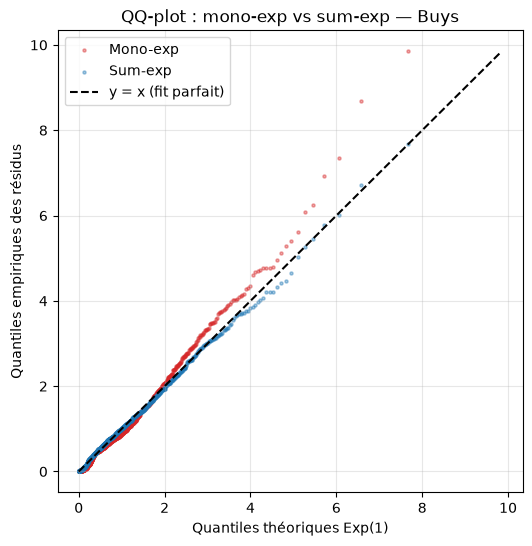

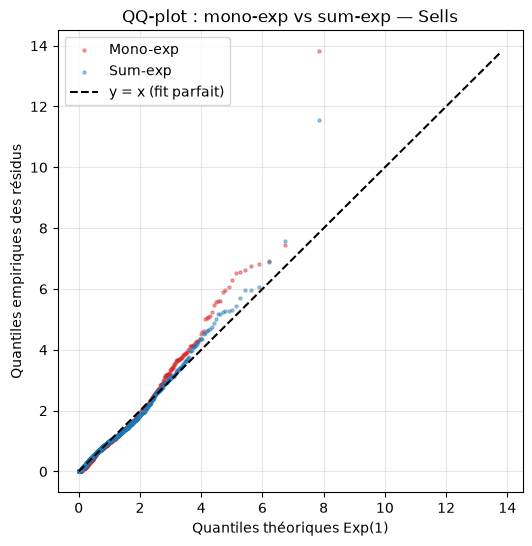

In [17]:
%matplotlib inline

def qq_overlay(resid_mono, resid_sum, title=""):
    def quantiles(u):
        u_sorted = np.sort(u)
        n = len(u_sorted)
        p = (np.arange(1, n + 1) - 0.5) / n
        return stats.expon.ppf(p), u_sorted   # (théoriques, empiriques)

    theo_m, emp_m = quantiles(resid_mono)
    theo_s, emp_s = quantiles(resid_sum)

    plt.figure(figsize=(6, 6))
    plt.scatter(theo_m, emp_m, s=5, alpha=0.4, label="Mono-exp", color="tab:red")
    plt.scatter(theo_s, emp_s, s=5, alpha=0.4, label="Sum-exp",  color="tab:blue")

    lim = max(theo_m.max(), emp_m.max(), theo_s.max(), emp_s.max())
    plt.plot([0, lim], [0, lim], 'k--', label="y = x (fit parfait)")

    plt.xlabel("Quantiles théoriques Exp(1)")
    plt.ylabel("Quantiles empiriques des résidus")
    plt.title(f"QQ-plot : mono-exp vs sum-exp — {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Dimension Buys
qq_overlay(v1, u1, "Buys")
# Dimension Sells
qq_overlay(v2, u2, "Sells")